# Movie Genre Classification

## INSTRUCCIONES


Classify a movie genre based on its plot.

<img src="https://raw.githubusercontent.com/sergiomora03/AdvancedTopicsAnalytics/main/notebooks/img/moviegenre.png"
     style="float: left; margin-right: 10px;" />



### Data

Input:
- movie plot

Output:
Probability of the movie belong to each genre


### Evaluation

- 30% Report with all the details of the solution, the analysis and the conclusions. The report cannot exceed 10 pages, must be send in PDF format and must be self-contained.
- 30% Code with the data processing and models developed that support the reported results.
- 30% Presentation of no more than 15 minutes with the main results of the project.
- 10% Model performance achieved. Metric: "AUC".

• The project must be carried out in groups of 4 people.
• Use clear and rigorous procedures.
• The delivery of the project is on March 15th, 2024, 11:59 pm, through email with Github link.
• No projects will be received after the delivery time or by any other means than the one established.




### Acknowledgements

We thank Professor Fabio Gonzalez, Ph.D. and his student John Arevalo for providing this dataset.

See https://arxiv.org/abs/1702.01992

## MODELO BASE

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

In [ ]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [ ]:
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [ ]:
dataTesting.head()

,year,title,plot
1,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ...."
4,1978,Midnight Express,"the true story of billy hayes , an american c..."
5,1996,Primal Fear,martin vail left the chicago da ' s office to ...
6,1950,Crisis,husband and wife americans dr . eugene and mr...
7,1959,The Tingler,the coroner and scientist dr . warren chapin ...


### Create count vectorizer


In [ ]:
vect = CountVectorizer(max_features=1000)
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

(7895, 1000)

In [ ]:
print(list(vect.vocabulary_.keys())[:50])

['most', 'is', 'the', 'story', 'of', 'single', 'father', 'who', 'takes', 'his', 'year', 'old', 'son', 'to', 'work', 'with', 'him', 'at', 'where', 'he', 'day', 'before', 'boy', 'meets', 'woman', 'train', 'drug', 'goes', 'into', 'room', 'and', 'tells', 'stay', 'ship', 'comes', 'though', 'it', 'arrive', 'an', 'later', 'happens', 'sees', 'this', 'tries', 'not', 'able', 'see', 'just', 'as', 'falls']


### Create y

In [ ]:
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))

le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

In [ ]:
y_genres

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0]])

In [ ]:
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

### Train multi-class multi-label model

In [ ]:
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))

In [ ]:
clf.fit(X_train, y_train_genres)

OneVsRestClassifier(estimator=RandomForestClassifier(max_depth=10, n_jobs=-1,
                                                     random_state=42))

In [ ]:
y_pred_genres = clf.predict_proba(X_test)

In [ ]:
roc_auc_score(y_test_genres, y_pred_genres, average='macro')

np.float64(0.7717668029296991)

## IMPORTAR LIBRERIAS

In [ ]:
!python -m spacy download en_core_web_trf
!pip install --upgrade lightgbm
!pip install spacy_transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 2.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 20.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score,accuracy_score

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC
import spacy

import nltk
from nltk.corpus import stopwords
import re

#import spacy_transformers
import multiprocessing
from sklearn.pipeline import Pipeline
import xgboost as xgb
from collections import Counter

from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
import multiprocessing

import ast
from sklearn.preprocessing import MultiLabelBinarizer

from itertools import product
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier


## CARGAR DATA

##ANÁLISIS EXPLORATORIO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Cargar los datos
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip')
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip')

### Descripción de los datos

In [ ]:
# 1. Análisis Estructural
print("="*80)
print("ANÁLISIS ESTRUCTURAL DE LOS DATOS")
print("="*80)
print("\nConjunto de Entrenamiento:")
print("-"*40)
print(f"Número de registros: {dataTraining.shape[0]:,}")
print(f"Número de variables: {dataTraining.shape[1]:,}")
print("\nConjunto de Prueba:")
print("-"*40)
print(f"Número de registros: {dataTesting.shape[0]:,}")
print(f"Número de variables: {dataTesting.shape[1]:,}")

# 2. Tipos de Datos y Valores Faltantes
print("\n")
print("="*80)
print("TIPOS DE DATOS Y VALORES FALTANTES")
print("="*80)

def print_info(df, nombre):
    print(f"\n{nombre}:")
    print("-"*40)
    for col in df.columns:
        nulls = df[col].isnull().sum()
        pct_nulls = (nulls/len(df))*100
        print(f"{col:15} : {str(df[col].dtype):10} | Nulos: {nulls:,} ({pct_nulls:.2f}%)")

print_info(dataTraining, "Conjunto de Entrenamiento")
print_info(dataTesting, "Conjunto de Prueba")

ANÁLISIS ESTRUCTURAL DE LOS DATOS

Conjunto de Entrenamiento:
----------------------------------------
Número de registros: 7,895
Número de variables: 7

Conjunto de Prueba:
----------------------------------------
Número de registros: 3,383
Número de variables: 5


TIPOS DE DATOS Y VALORES FALTANTES

Conjunto de Entrenamiento:
----------------------------------------
Unnamed: 0      : int64      | Nulos: 0 (0.00%)
year            : int64      | Nulos: 0 (0.00%)
title           : object     | Nulos: 0 (0.00%)
plot            : object     | Nulos: 0 (0.00%)
genres          : object     | Nulos: 0 (0.00%)
rating          : float64    | Nulos: 0 (0.00%)
plot_length     : int64      | Nulos: 0 (0.00%)

Conjunto de Prueba:
----------------------------------------
Unnamed: 0      : int64      | Nulos: 0 (0.00%)
year            : int64      | Nulos: 0 (0.00%)
title           : object     | Nulos: 0 (0.00%)
plot            : object     | Nulos: 0 (0.00%)
plot_length     : int64      | Nulos: 0

Para el desarrollo de este proyecto se utilizaron datos con información de películas distribuidos en dos conjuntos: entrenamiento y prueba. El conjunto de entrenamiento contiene 7,895 registros con seis variables que incluyen: un identificador (int64), año (int64), título (object), trama (object), géneros (object) y rating (float64). Por su parte, el conjunto de prueba consta de 3,383 registros con cuatro variables, manteniendo solo el identificador, año, título y trama, excluyendo las variables de géneros y rating que serán objeto de predicción. Es importante resaltar que ambos conjuntos presentan datos completos, sin valores faltantes en ninguna de sus variables, lo que asegura la calidad de la información para el desarrollo del modelo.

Analizando las estadísticas de longitud de las tramas, observamos características similares entre ambos conjuntos:



ESTADÍSTICAS DE LONGITUD DE LAS TRAMAS

Conjunto de Entrenamiento:
----------------------------------------
count           : 7,895.00
mean            : 748.82
std             : 494.77
min             : 3.00
25%             : 412.00
50%             : 655.00
75%             : 951.50
max             : 9,408.00

Conjunto de Prueba:
----------------------------------------
count           : 3,383.00
mean            : 749.44
std             : 486.16
min             : 8.00
25%             : 419.00
50%             : 650.00
75%             : 941.00
max             : 3,863.00


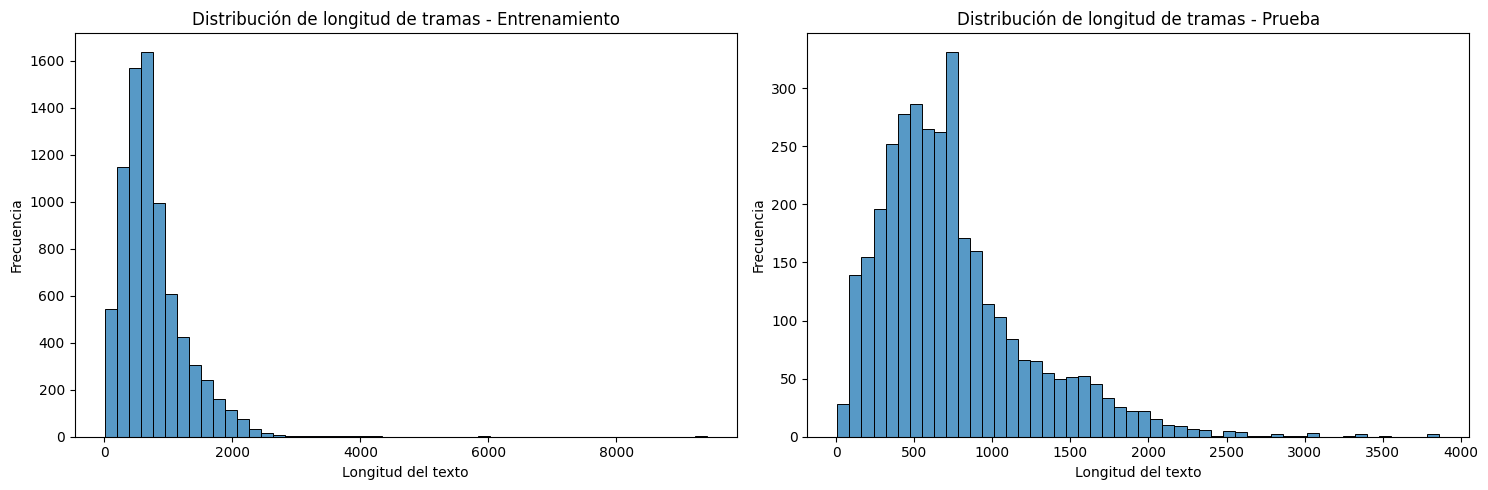

In [ ]:
# 3. Estadísticas de longitud de texto
print("\n")
print("="*80)
print("ESTADÍSTICAS DE LONGITUD DE LAS TRAMAS")
print("="*80)

def plot_stats(df, nombre):
    df['plot_length'] = df['plot'].str.len()
    stats = df['plot_length'].describe()
    print(f"\n{nombre}:")
    print("-"*40)
    for stat, value in stats.items():
        print(f"{stat:15} : {value:,.2f}")

plot_stats(dataTraining, "Conjunto de Entrenamiento")
plot_stats(dataTesting, "Conjunto de Prueba")

# 4. Visualización de la distribución de longitudes
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=dataTraining['plot'].str.len(), bins=50)
plt.title('Distribución de longitud de tramas - Entrenamiento')
plt.xlabel('Longitud del texto')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data=dataTesting['plot'].str.len(), bins=50)
plt.title('Distribución de longitud de tramas - Prueba')
plt.xlabel('Longitud del texto')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


En el Conjunto de Entrenamiento la longitud media de las tramas es de 748.82 caracteres, con una desviación estándar de 494.77. La trama más corta tiene 3 caracteres y la más larga 9,408. El 50% de las tramas tiene entre 412 (25%) y 951.50 (75%) caracteres, con una mediana de 655 caracteres. Y en el Conjunto de Prueba se presenta características similares, con una media de 749.44 caracteres y una desviación estándar de 486.16. La trama más corta tiene 8 caracteres y la más larga 3,863. El 50% de las tramas tiene entre 419 (25%) y 941 (75%) caracteres, con una mediana de 650 caracteres.


### Exploración de los datos

ANÁLISIS TEMPORAL


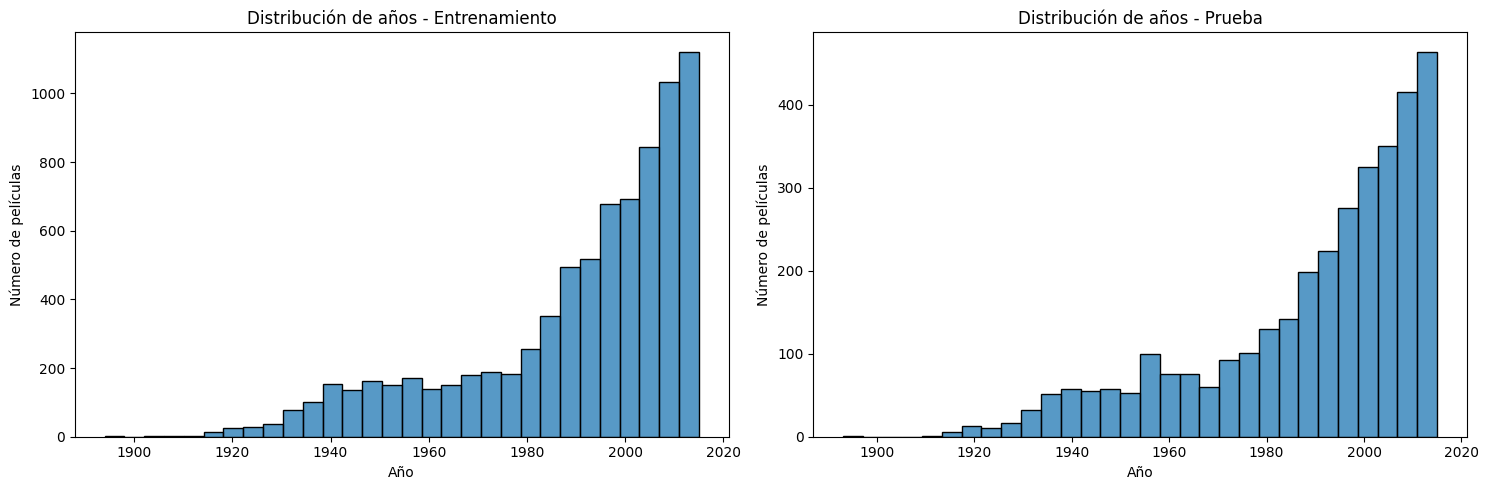

In [ ]:
# 1. Análisis temporal (ambos conjuntos)
print("="*80)
print("ANÁLISIS TEMPORAL")
print("="*80)

# Distribución de películas por año
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=dataTraining, x='year', bins=30)
plt.title('Distribución de años - Entrenamiento')
plt.xlabel('Año')
plt.ylabel('Número de películas')

plt.subplot(1, 2, 2)
sns.histplot(data=dataTesting, x='year', bins=30)
plt.title('Distribución de años - Prueba')
plt.xlabel('Año')
plt.ylabel('Número de películas')
plt.tight_layout()
plt.show()

La distribución temporal de los datos abarca desde 1900 hasta 2020, donde se observa un crecimiento exponencial a partir de 1980. El período 2000-2020 concentra la mayor cantidad de películas, con más de 800 películas por año en el conjunto de entrenamiento y más de 300 en el de prueba. Esta distribución similar entre ambos conjuntos muestra una representatividad adecuada de la muestra de prueba, aunque indica un sesgo hacia el cine moderno.



ANÁLISIS DE GÉNEROS (Conjunto de Entrenamiento)


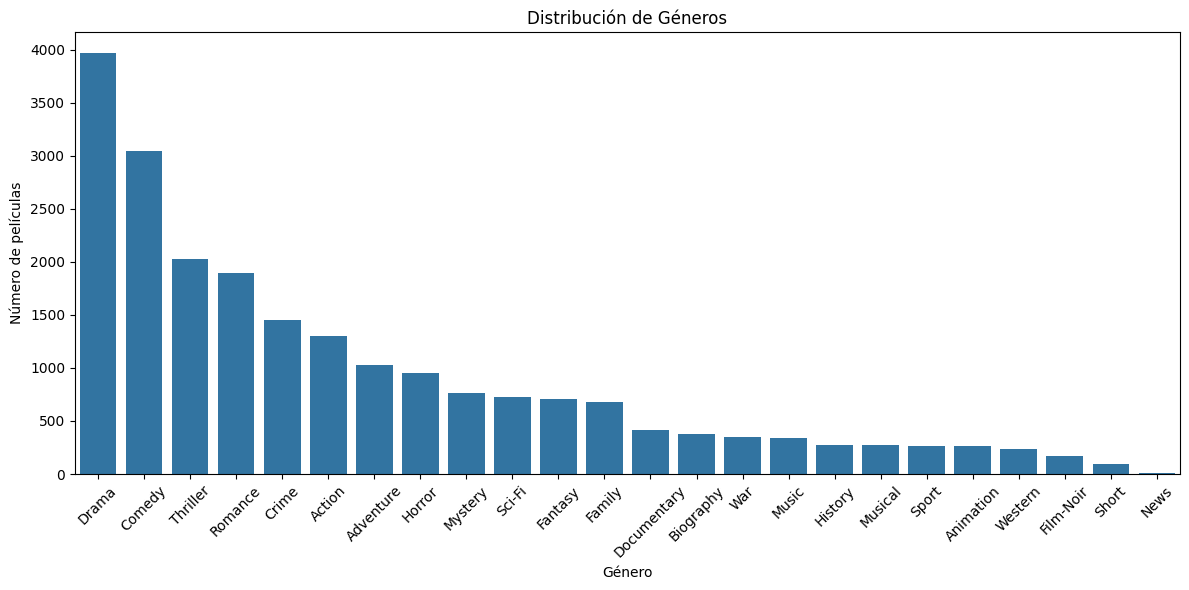

In [ ]:
# 2. Análisis de géneros (solo training)
print("\n")
print("="*80)
print("ANÁLISIS DE GÉNEROS (Conjunto de Entrenamiento)")
print("="*80)

# Separar los géneros
genres_list = [genres.strip("[]").replace("'", "").split(", ")
               for genres in dataTraining['genres']]

# Contar frecuencia de cada género
genre_counts = Counter([genre for sublist in genres_list for genre in sublist])

# Convertir a DataFrame
genre_df = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['count'])
genre_df = genre_df.sort_values('count', ascending=False)

# Visualización de géneros
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_df, x=genre_df.index, y='count')
plt.title('Distribución de Géneros')
plt.xticks(rotation=45)
plt.xlabel('Género')
plt.ylabel('Número de películas')
plt.tight_layout()
plt.show()

La gráfica de la distribución de géneros muestra tres grupos claramente diferenciados. El primer grupo, conformado por Drama, Comedia, Thriller y Romance, domina la distribución con más de 1,500 películas cada uno, siendo Drama el género predominante. Un segundo grupo de géneros como Crime, Action, Adventure y Horror mantiene una presencia moderada. El tercer grupo, que incluye géneros como Documentary, Biography, War y géneros más especializados como Musical, Sport y News, tiene una representación significativamente menor. Esta estratificación en la distribución de géneros plantea desafíos importantes para el modelo, ya que deberá manejar eficazmente tanto géneros altamente representados como aquellos con muy pocos ejemplos de entrenamiento.



ANÁLISIS DE RATINGS (Conjunto de Entrenamiento)


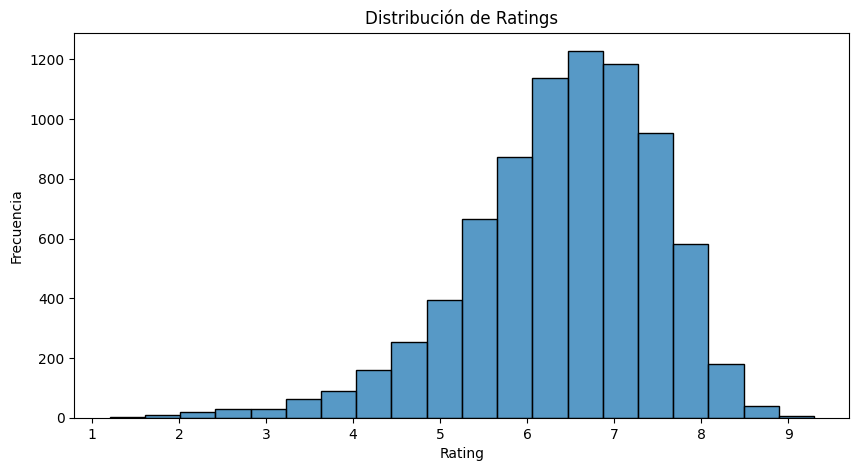


Estadísticas de ratings:
count    7895.000000
mean        6.402812
std         1.078260
min         1.200000
25%         5.800000
50%         6.500000
75%         7.200000
max         9.300000
Name: rating, dtype: float64


In [ ]:

# 3. Análisis de ratings (solo training)
print("\n")
print("="*80)
print("ANÁLISIS DE RATINGS (Conjunto de Entrenamiento)")
print("="*80)

plt.figure(figsize=(10, 5))
sns.histplot(data=dataTraining, x='rating', bins=20)
plt.title('Distribución de Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

# Estadísticas descriptivas
print("\nEstadísticas de ratings:")
print(dataTraining['rating'].describe())



La gráfica de distribución de ratings muestra una distribución que se aproxima a una curva normal, con un sesgo hacia calificaciones positivas. La calificación promedio es de 6.40, con una desviación estándar de 1.07, lo que indica una variabilidad moderada en las opiniones. La mayoría de las películas se concentran en el rango de 6 a 7 estrellas, con el pico más alto alrededor de 6.5. Las calificaciones extremas (por debajo de 4 y por encima de 8) son relativamente poco comunes, lo que sugiere una tendencia central en la evaluación de películas. Esta distribución relativamente equilibrada de ratings facilitará el entrenamiento del modelo al proporcionar ejemplos representativos en diferentes niveles de calificación, aunque con un énfasis en el rango medio-alto.

###Revisión de la calidad de los datos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re

# Cargar datos
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip')

Para evaluar la calidad y características de los datos disponibles, se realizaron los siguientes análisis:

<Figure size 1500x800 with 0 Axes>

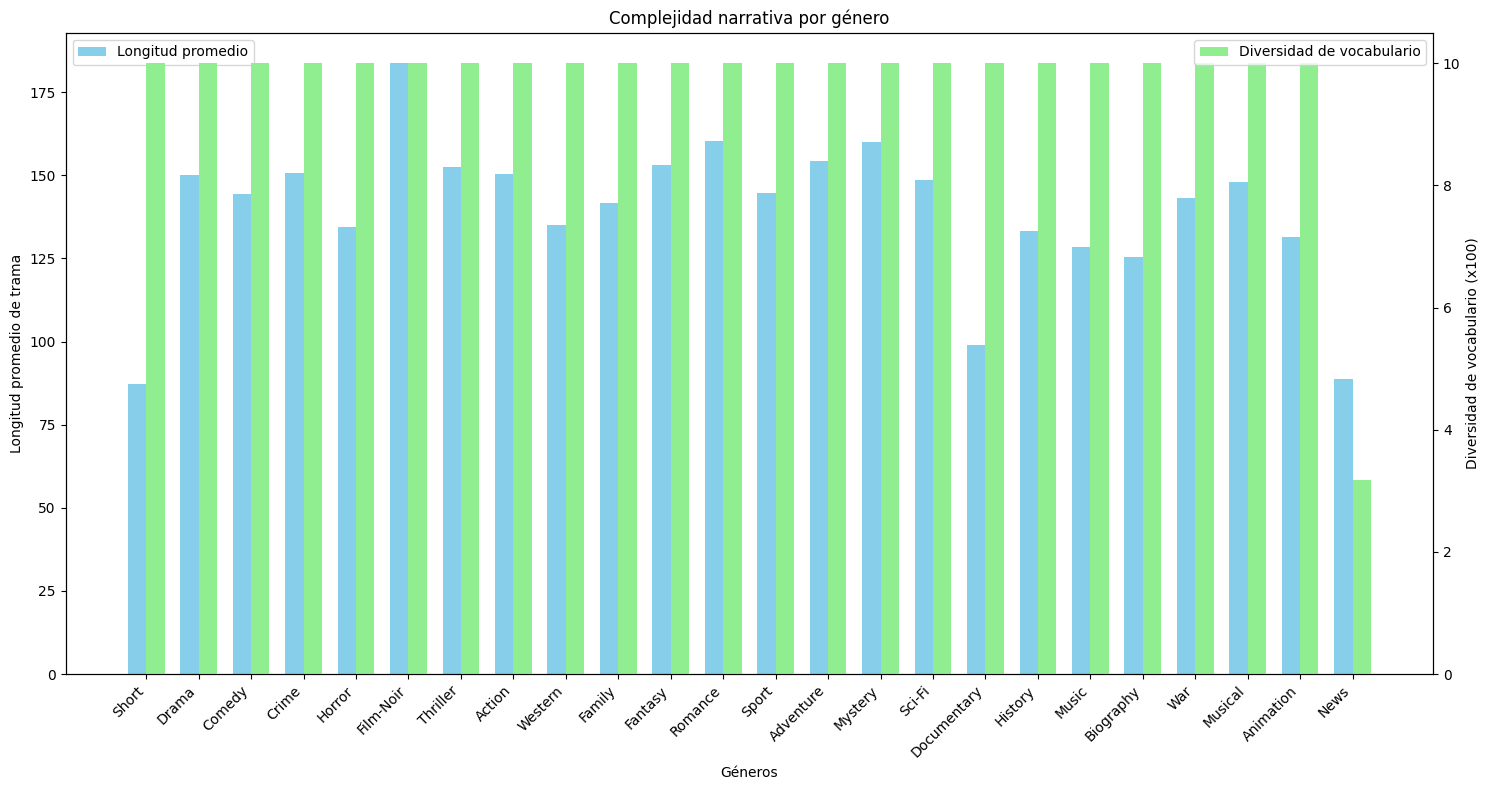

In [ ]:
# Preparar datos por género
genre_docs = defaultdict(list)
for idx, row in dataTraining.iterrows():
    genres = eval(row['genres'])
    for genre in genres:
        genre_docs[genre].append(row['plot'])

# Obtener todos los géneros únicos
all_genres = list(genre_docs.keys())

# Análisis de complejidad narrativa por género
genre_complexity = {}
for genre in all_genres:
    # Calcular longitud promedio de tramas
    avg_length = np.mean([len(doc.split()) for doc in genre_docs[genre]])
    # Calcular diversidad de vocabulario
    vectorizer = TfidfVectorizer(max_features=1000)
    dtm = vectorizer.fit_transform(genre_docs[genre])
    vocab_diversity = len(vectorizer.get_feature_names_out())
    genre_complexity[genre] = (avg_length, vocab_diversity)

# Visualizar complejidad narrativa
plt.figure(figsize=(15, 8))
genres = list(genre_complexity.keys())
avg_lengths = [x[0] for x in genre_complexity.values()]
vocab_sizes = [x[1]/100 for x in genre_complexity.values()]

x = np.arange(len(genres))
width = 0.35

fig, ax1 = plt.subplots(figsize=(15, 8))
ax2 = ax1.twinx()

rects1 = ax1.bar(x - width/2, avg_lengths, width, label='Longitud promedio', color='skyblue')
rects2 = ax2.bar(x + width/2, vocab_sizes, width, label='Diversidad de vocabulario', color='lightgreen')

ax1.set_xlabel('Géneros')
ax1.set_ylabel('Longitud promedio de trama')
ax2.set_ylabel('Diversidad de vocabulario (x100)')

ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Complejidad narrativa por género')
plt.tight_layout()
plt.show()


El gráfico de complejidad narrativa por género muestra patrones interesantes en la forma en que se escriben las tramas de diferentes géneros cinematográficos: En términos de longitud promedio, los géneros Drama, Film-Noir y Thriller muestran las tramas más extensas, lo que sugiere una tendencia hacia narrativas más desarrolladas y complejas. En contraste, géneros como Short, News y Animation tienden a tener tramas más concisas, lo cual es coherente con su naturaleza y formato.

En cuanto a la diversidad de vocabulario, es notable que la mayoría de los géneros mantienen un nivel similar de riqueza léxica (como se muestra en las barras verdes), lo que indica un estándar consistente en la variedad de lenguaje utilizado. Sin embargo, hay algunas excepciones notables, como News que muestra una diversidad de vocabulario significativamente menor, posiblemente debido a su enfoque más directo.


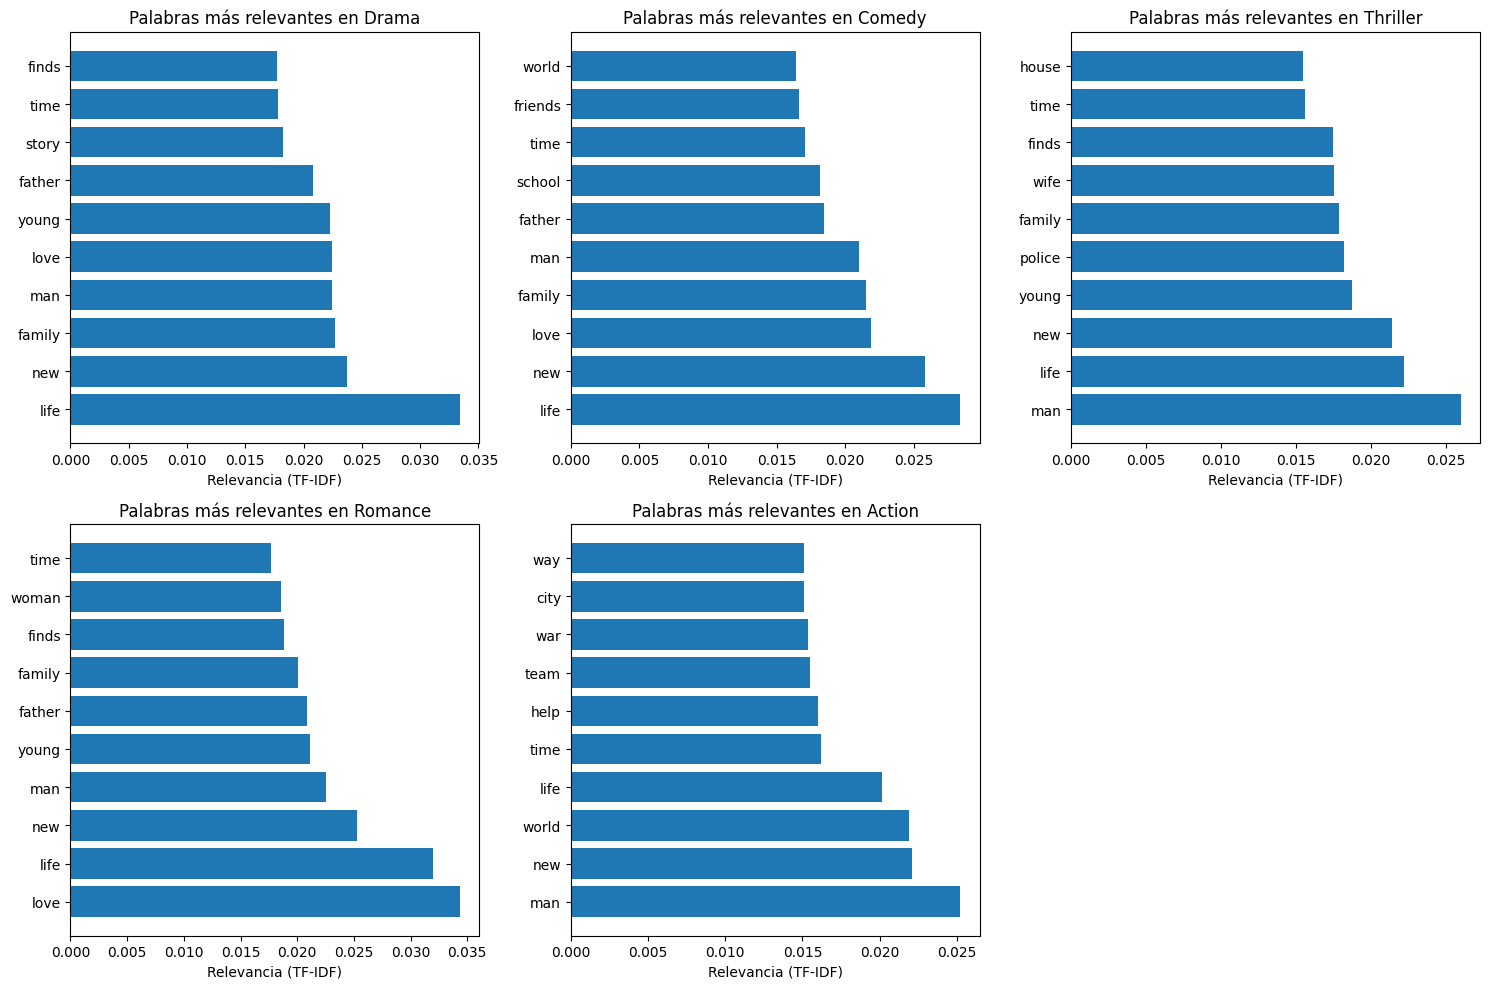

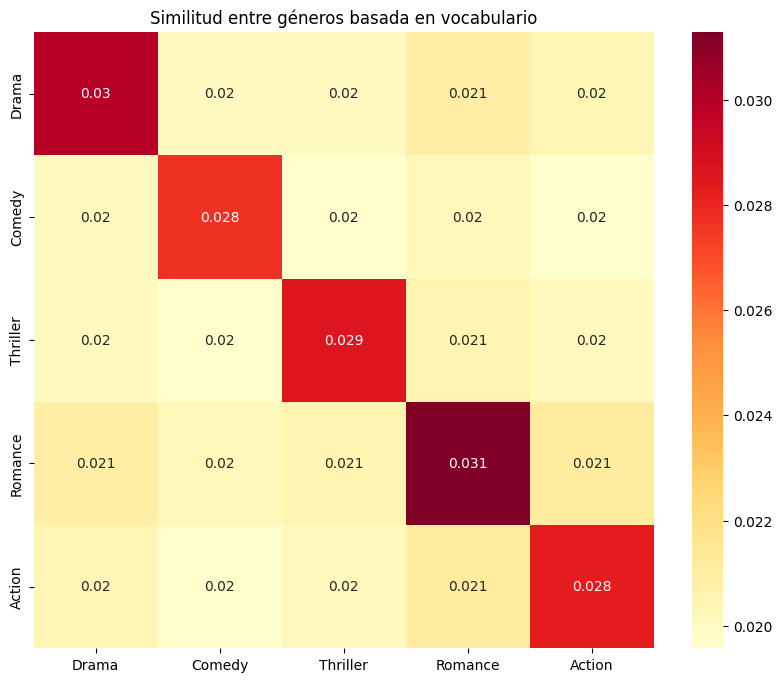

In [ ]:
# Preprocesamiento de texto
def preprocess_text(text):
    # Convertir a minúsculas y eliminar caracteres especiales
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Preprocesar todas las tramas
dataTraining['processed_plot'] = dataTraining['plot'].apply(preprocess_text)

# Crear diccionario de películas por género
genre_docs = defaultdict(list)
for idx, row in dataTraining.iterrows():
    genres = eval(row['genres'])
    for genre in genres:
        genre_docs[genre].append(row['processed_plot'])

# Configurar vectorizador TF-IDF
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',  # Aquí está la corrección
    min_df=5
)

# Analizar palabras más relevantes por género
def get_top_words_for_genre(genre, n_words=10):
    tfidf_matrix = vectorizer.fit_transform(genre_docs[genre])
    feature_names = vectorizer.get_feature_names_out()
    avg_tfidf = tfidf_matrix.mean(axis=0).A1
    top_indices = avg_tfidf.argsort()[-n_words:][::-1]
    return [(feature_names[i], avg_tfidf[i]) for i in top_indices]

# Visualizar palabras más relevantes para los géneros principales
main_genres = ['Drama', 'Comedy', 'Thriller', 'Romance', 'Action']

plt.figure(figsize=(15, 10))
for i, genre in enumerate(main_genres):
    top_words = get_top_words_for_genre(genre)
    plt.subplot(2, 3, i+1)
    words, values = zip(*top_words)
    plt.barh(words, values)
    plt.title(f'Palabras más relevantes en {genre}')
    plt.xlabel('Relevancia (TF-IDF)')
plt.tight_layout()
plt.show()

# Matriz de similitud entre géneros
genre_vectors = {}
for genre in main_genres:
    tfidf_matrix = vectorizer.fit_transform(genre_docs[genre])
    genre_vectors[genre] = tfidf_matrix.mean(axis=0).A1

similarity_matrix = np.zeros((len(main_genres), len(main_genres)))
for i, genre1 in enumerate(main_genres):
    for j, genre2 in enumerate(main_genres):
        similarity = np.dot(genre_vectors[genre1], genre_vectors[genre2])
        similarity_matrix[i, j] = similarity

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix,
            xticklabels=main_genres,
            yticklabels=main_genres,
            annot=True,
            cmap='YlOrRd')
plt.title('Similitud entre géneros basada en vocabulario')
plt.show()


El análisis de las palabras más relevantes por género revela patrones lingüísticos distintivos y superposiciones que caracterizan a cada categoría cinematográfica. En Drama, Comedy y Romance predominan términos relacionados con relaciones personales y experiencias vitales ('life', 'love', 'family'), mientras que Thriller y Action se caracterizan por palabras que sugieren conflicto y tensión ('police', 'war'). Es destacable la presencia universal de elementos temporales ('time', 'new') y referencias a la individualidad ('man', 'young') en todos los géneros, aunque con diferentes connotaciones según el contexto: desde el desarrollo personal en Drama hasta la acción en Thriller. Esta superposición de vocabulario con distintos significados según el género representa un aspecto a considerar en el desarrollo del modelo ya que sugiere la necesidad de un análisis contextual más profundo que la simple identificación de palabras clave.

El mapa de calor de similitud entre géneros ofrece una visualización de las relaciones léxicas identificadas en el análisis anterior. Los valores más altos en la diagonal (Drama 0.03, Comedy 0.028, Thriller 0.029, Romance 0.031, Action 0.028) confirman que cada género mantiene un vocabulario distintivo. Sin embargo, se pueden ver las similitudes entre géneros: por ejemplo, la conexión entre Drama y Comedy (0.02) refleja el uso compartido de términos relacionados con la vida cotidiana y las relaciones personales que observamos en sus palabras más relevantes ('life', 'family', 'love'). Romance muestra la mayor distintividad en su vocabulario (0.031), lo que se evidencia en su uso único de términos específicos como 'woman' junto con 'love'. Esta matriz de similitud refuerza la necesidad de que el modelo considere no solo la presencia de ciertas palabras, sino también su contexto específico dentro de cada género.

## VERIFICACIÓN Y PREPARACIÓN DE DATOS

In [ ]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [ ]:
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [ ]:
dataTesting.head()

,year,title,plot
1,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ...."
4,1978,Midnight Express,"the true story of billy hayes , an american c..."
5,1996,Primal Fear,martin vail left the chicago da ' s office to ...
6,1950,Crisis,husband and wife americans dr . eugene and mr...
7,1959,The Tingler,the coroner and scientist dr . warren chapin ...


## MODELAMIENTO

##### Preparación data lenguaje natural

Empezamos aplicando un modelo sencillo, el cuál aplica la estrategia de bolsa de palabras y también predice a partir de un modelo Random Forest sencillo

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

#Create counter vectorizer
vect = CountVectorizer(max_features=1000)
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

#Create Y
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))

le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

#Separate data in train and test
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

#Train multiclass multilabel model
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))

#Train model
clf.fit(X_train, y_train_genres)

#Predict test
y_pred_genres = clf.predict_proba(X_test)

#Calculate ROC AUC
roc_auc_score(y_test_genres, y_pred_genres, average='macro')



np.float64(0.7717668029296991)

 Ahora aplicamos N-gramas. Este código se encarga de transformar el texto de las descripciones de las películas en una representación numérica que las máquinas puedan entender. Para ello, utiliza CountVectorizer, una herramienta que cuenta la frecuencia de las palabras. La particularidad aquí es el uso de "n-gramas", que no solo considera palabras individuales (unigramas), sino también pares (bigramas) y tríos (trigramas) de palabras. Esto es crucial para capturar el contexto y las frases importantes en las descripciones. Al limitar el vocabulario a las 1000 palabras/n-gramas más frecuentes, se reduce la dimensionalidad y se enfoca el análisis en los términos más relevantes.

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

# Apply n-grams to CountVectorizer
vect = CountVectorizer(max_features=1000, ngram_range=(1,3))
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

# Create Y
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))

le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

# Separate data in train and test
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

# Train multiclass multilabel model
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))

# Train model
clf.fit(X_train, y_train_genres)

# Predict test
y_pred_genres = clf.predict_proba(X_test)

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test_genres, y_pred_genres, average='macro')

print(f"ROC AUC: {roc_auc}")

ROC AUC: 0.7501806494097139


Aplicaremos TF-IDF. Este bloque inicial se enfoca en transformar las descripciones de las películas (la columna 'plot') en una representación numérica adecuada para el análisis de aprendizaje automático. A diferencia del ejemplo anterior que usaba CountVectorizer, aquí se emplea TfidfVectorizer. Esta técnica no solo cuenta la frecuencia de las palabras, sino que también pondera su importancia mediante el esquema TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF reduce el peso de las palabras comunes y aumenta el de las palabras que son distintivas para cada documento. Además, se utilizan n-gramas (unigramas, bigramas, trigramas y 4-gramas), lo que permite capturar el contexto y las frases relevantes en las descripciones. El parámetro max_features=1000 limita el vocabulario a las 1000 palabras/n-gramas más importantes, lo que ayuda a reducir la dimensionalidad y enfocar el análisis en los términos más significativos.

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer # Changed CountVectorizer to TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

# Apply TF-IDF to text vectorization
vect = TfidfVectorizer(max_features=1000, ngram_range=(1, 4))  # Using unigrams and bigrams
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

# Create Y
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))

le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

# Separate data in train and test
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

# Train multiclass multilabel model
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))

# Train model
clf.fit(X_train, y_train_genres)

# Predict test
y_pred_genres = clf.predict_proba(X_test)

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test_genres, y_pred_genres, average='macro')

print(f"ROC AUC: {roc_auc}")

ROC AUC: 0.7517607155948793


Ahora se aplica tokenización. La "tokenización" es un proceso fundamental en el procesamiento del lenguaje natural (PLN) y en la seguridad de datos. Su propósito principal es dividir un texto o datos sensibles en unidades más pequeñas, llamadas "tokens", para facilitar su análisis o protección.

Este primer bloque define una función personalizada llamada nltk_tokenizer que se encargará de procesar el texto antes de la vectorización. Esta función toma un texto como entrada y realiza las siguientes operaciones:

* Tokenización: Divide el texto en palabras individuales utilizando la función nltk.word_tokenize de la biblioteca NLTK. Además, convierte todas las palabras a minúsculas para normalizar el texto.
* Eliminación de "stop words": Elimina las palabras comunes que no aportan mucho significado al análisis, como "el", "la", "los", "un", etc. Estas palabras se encuentran en una lista predefinida de "stop words" en inglés.
* Filtrado de caracteres no alfanuméricos: se asegura que solo se retornen palabras que sean alfanumericas.
Retorno de la lista de tokens: Devuelve una lista con las palabras resultantes, que serán utilizadas como tokens para la vectorización.

In [ ]:
import pandas as pd
import nltk
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from collections import Counter

# Descargar recursos de NLTK
nltk.download('punkt_tab')
nltk.download('stopwords')

# Cargar datos
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

# Función para tokenizar con NLTK y eliminar stopwords
def nltk_tokenizer(text):
    words = nltk.word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    return [word for word in words if word.isalnum() and word not in stop_words]

# Apply Count Vectorizer with custom tokenizer
vect = CountVectorizer(tokenizer=nltk_tokenizer, max_features=1000, ngram_range=(1, 4))
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

# Crear Y
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

# Entrenar modelo multiclase multilabel
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))

# Entrenar modelo
clf.fit(X_train, y_train_genres)

# Predecir en datos de prueba
y_pred_genres = clf.predict_proba(X_test)

# Calcular ROC AUC
roc_auc = roc_auc_score(y_test_genres, y_pred_genres, average='macro')

print(f"ROC AUC: {roc_auc}")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


ROC AUC: 0.7691740526652834


Ahora aplicaremos stemming y lematización. Este código implementa un proceso de análisis de texto para construir un modelo de clasificación multiclase y multietiqueta que predice los géneros de películas a partir de sus descripciones, utilizando lematización y stemming con NLTK, seguido de la vectorización con CountVectorizer. Inicialmente, se descargan los recursos de NLTK necesarios para la tokenización, eliminación de palabras comunes y lematización. Posteriormente, se cargan los datos de entrenamiento y prueba desde URLs de GitHub en DataFrames de pandas. Se inicializan los objetos WordNetLemmatizer (para la lematización) y PorterStemmer y SnowballStemmer (para el stemming), que se utilizarán para reducir las palabras a su forma base o raíz. Se define una función personalizada lemmatize_and_stem que toma un texto, lo tokeniza, elimina las palabras comunes, lematiza las palabras y aplica stemming con ambos algoritmos. La función devuelve una lista de las palabras resultantes, que serán utilizadas como tokens para la vectorización.  

La lematización y el stemming son técnicas de procesamiento del lenguaje natural que buscan simplificar el texto reduciendo las palabras a su forma base o raíz. El stemming realiza un recorte de sufijos y prefijos, siendo un proceso rápido pero que puede generar palabras sin significado. En contraste, la lematización reduce las palabras a su lema, una forma base que existe en el diccionario, considerando el contexto y la gramática, lo que resulta en una mayor precisión pero también en un proceso más complejo y lento. Ambas técnicas normalizan el texto, facilitando el análisis y la comparación de documentos, y su elección depende de las necesidades de la aplicación: velocidad con stemming o precisión con lematización.


In [ ]:
import pandas as pd
import nltk
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer, SnowballStemmer
from collections import Counter

# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Cargar datos
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

# Inicializar lematizador y stemmers
lematizador = WordNetLemmatizer()
stemmer_porter = PorterStemmer()
stemmer_snowball = SnowballStemmer('english')

# Función para lematizar y aplicar stemming
def lemmatize_and_stem(text):
    words = nltk.word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word.isalnum() and word not in stop_words]
    lemmatized_words = [lematizador.lemmatize(word) for word in filtered_words]
    stemmed_words_porter = [stemmer_porter.stem(word) for word in lemmatized_words]
    stemmed_words_snowball = [stemmer_snowball.stem(word) for word in lemmatized_words]
    return stemmed_words_snowball

# Aplicar lematización y stemming antes de CountVectorizer
dataTraining['processed_plot'] = dataTraining['plot'].apply(lemmatize_and_stem)

# Aplicar CountVectorizer en los datos procesados
vect = CountVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, max_features=1000, ngram_range=(1, 4))
X_dtm = vect.fit_transform(dataTraining['processed_plot'])
X_dtm.shape

# Crear Y
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

# Entrenar modelo multiclase multilabel
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))

# Entrenar modelo
clf.fit(X_train, y_train_genres)

# Predecir en datos de prueba
y_pred_genres = clf.predict_proba(X_test)

# Calcular ROC AUC
roc_auc = roc_auc_score(y_test_genres, y_pred_genres, average='macro')

print(f"ROC AUC: {roc_auc}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


ROC AUC: 0.7899140457789287


Ahora aplicaremos alguna libreria que sea buena para procesamiento de lenguaje como SPACY. Este código implementa un proceso de análisis de texto para construir un modelo de clasificación multiclase y multietiqueta que predice los géneros de películas a partir de sus descripciones, utilizando spaCy para el procesamiento del texto y CountVectorizer para la vectorización. Primero, se define una función spacy_process que toma un texto, lo procesa con spaCy, extrae los lemas de las palabras y filtra las palabras, incluyendo solo las alfabéticas y excluyendo las palabras vacías. Esta función se aplica a la columna 'plot' del DataFrame dataTraining, creando una nueva columna 'processed_plot' con las listas de lemas procesados. Luego, se utiliza CountVectorizer para transformar estas listas en una matriz de recuento de términos, indicando que no realice ninguna tokenización o preprocesamiento adicional. Se prepara la variable objetivo, los géneros de las películas, utilizando MultiLabelBinarizer.

spaCy es una biblioteca de Python diseñada para el procesamiento avanzado del lenguaje natural (PLN), destacando por su eficiencia y velocidad, lo que la hace ideal para aplicaciones en producción. Ofrece herramientas para un análisis lingüístico profundo, incluyendo tokenización, etiquetado de partes del discurso, análisis de dependencia, reconocimiento de entidades nombradas y lematización, todo ello con modelos pre-entrenados para varios idiomas, lo que facilita su uso sin necesidad de entrenar modelos desde cero.


In [ ]:
import pandas as pd
import spacy
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from collections import Counter

# Cargar modelo de spaCy
nlp = spacy.load("en_core_web_sm")

# Cargar datos
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

# Función para procesar texto con spaCy
def spacy_process(text):
    doc = nlp(text.lower())
    return [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

# Aplicar spaCy antes de CountVectorizer
dataTraining['processed_plot'] = dataTraining['plot'].apply(spacy_process)

# Aplicar CountVectorizer en los datos procesados
vect = CountVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, max_features=1000, ngram_range=(1, 4))
X_dtm = vect.fit_transform(dataTraining['processed_plot'])
X_dtm.shape

# Crear Y
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres'])

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

# Entrenar modelo multiclase multilabel
clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))

# Entrenar modelo
clf.fit(X_train, y_train_genres)

# Predecir en datos de prueba
y_pred_genres = clf.predict_proba(X_test)

# Calcular ROC AUC
roc_auc = roc_auc_score(y_test_genres, y_pred_genres, average='macro')

print(f"ROC AUC: {roc_auc}")

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


ROC AUC: 0.7947132530950917


Lo visto anteriormente demuestra que hay algunos procedimientos que funcionaron mejore para el tratamiento de la data y los que aportaron a tener un mejor AUC de test se aplican para la preparación final de la data. Los "pre-procesamientos" que mejor resultado dieron fue la aplicación de stopwords, stemming y lematización. Cabe aclarar que aún no usaremos librerias de modelos pre entrenados para intentar llegar al AUC deseado de una forma más sencilla  propia


In [ ]:
import nltk  # Importa la biblioteca NLTK (Natural Language Toolkit)
nltk.download('punkt')  # Descarga el tokenizador punkt (para dividir texto en oraciones y palabras)
nltk.download('wordnet')  # Descarga WordNet (base de datos léxica para lematización)
nltk.download('stopwords') # Descarga la lista de palabras vacías (stopwords) para el inglés
stopwords = stopwords.words('english') #Carga la lista de stop words.

import ast  # Importa el módulo ast (Abstract Syntax Trees) para evaluar literales de forma segura
import pandas as pd  # Importa la biblioteca pandas para manipulación de datos
import numpy as np  # Importa la biblioteca numpy para operaciones numéricas
from sklearn.feature_extraction.text import CountVectorizer  # Importa CountVectorizer para convertir texto en matriz de conteo de tokens
from sklearn.preprocessing import MultiLabelBinarizer  # Importa MultiLabelBinarizer para convertir listas de géneros en formato binario
from sklearn.multiclass import OneVsRestClassifier  # Importa OneVsRestClassifier para clasificación multiclase
from sklearn.ensemble import RandomForestClassifier  # Importa RandomForestClassifier para el modelo de clasificación
from sklearn.metrics import roc_auc_score  # Importa roc_auc_score para evaluar el rendimiento del modelo
from sklearn.model_selection import train_test_split  # Importa train_test_split para dividir datos en entrenamiento y prueba

# Función para evaluar literales de forma segura
def safe_literal_eval(x):
    try:
        return ast.literal_eval(x)  # Intenta evaluar el literal
    except (ValueError, SyntaxError):
        return x  # Retorna el valor original si no es un literal válido

# Carga el DataFrame de datos de entrenamiento desde un archivo
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)

# Aplica la función safe_literal_eval a la columna 'genres' para convertir las cadenas de géneros en listas
dataTraining['genres'] = dataTraining['genres'].apply(safe_literal_eval)

# Inicializa el MultiLabelBinarizer y Vectoriza los géneros del conjunto de entrenamiento (convierte listas de géneros en formato binario)
matriz = MultiLabelBinarizer()
y = matriz.fit_transform(dataTraining['genres'])

# Inicializa el lematizador WordNetLemmatizer y el stemmer PorterStemmer, al igual que el stemmer SnowballStemmer para inglés
lematizador = WordNetLemmatizer()
stemming = PorterStemmer()

#Aplicaremos la eliminación de stopwords, los caracteres diferentes, eliminaremos espacios en blanco y aplicaremos lematización con stemming
def preprocesamiento(text):
    # Convertir todo a lowercase
    text = text.str.lower()

    # Eliminar stopwords
    text = text.apply(lambda x: ' '.join([word for word in x.split() if word not in stopwords]))

    # Quitar caracteres que no sean letras (Se eliminan caracteres especiales y números)
    text = text.apply(lambda x: ' '.join([re.sub(r'[^a-zA-Z]', '', word) for word in x.split()]))

    # Quitar espacios en blanco
    text = text.apply(lambda x: ' '.join(x.split()))

    # Lematización
    text = text.apply(lambda x: ' '.join([lematizador.lemmatize(word) for word in x.split()]))

    # Stemming (usando Porter Stemmer)
    text = text.apply(lambda x: ' '.join([stemming.stem(word) for word in x.split()]))

    return text

dataTraining['plot'] = preprocesamiento(dataTraining['plot'])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Vector
vectxg = CountVectorizer(min_df=3,binary = True)
X = vectxg.fit_transform(dataTraining['plot'])
X.shape

(7895, 11020)

In [ ]:
#Partición Train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Ahora se hacen varios modelos para tener diferentes alternativas y validar diferentes opciones para llegar al AUC ideal

##### XGBOOST CLASSIFIER

Nuestro primer modelo es un XGBOOST CLASIFIER ya que es un caso de multiples categorias. Inicialmente, se importan las bibliotecas necesarias: Optuna para la optimización de hiperparámetros, XGBoost como el algoritmo de aprendizaje automático a optimizar, pandas para la manipulación de datos (aunque no se usa explícitamente en el fragmento), numpy para operaciones numéricas, y las funciones roc_auc_score y train_test_split de scikit-learn para evaluar el rendimiento del modelo y dividir los datos, respectivamente. Se asume que las variables X e y (datos de características y variable objetivo) ya están definidas y divididas en conjuntos de entrenamiento (X_train, y_train) y prueba (X_test, y_test).

La pieza central de la optimización es la función objective(trial). Esta función toma un objeto trial de Optuna como entrada, el cual permite sugerir diferentes valores para los hiperparámetros del modelo XGBoost dentro de un espacio de búsqueda definido. Dentro de esta función, se define un diccionario param que contiene los hiperparámetros a optimizar. Para cada hiperparámetro, se utiliza un método de sugerencia de trial, como suggest_loguniform para rangos continuos con escala logarítmica, suggest_uniform para rangos continuos con escala lineal, y suggest_int para rangos de enteros. Los hiperparámetros explorados incluyen parámetros de regularización (alpha, reg_lambda), muestreo (subsample, colsample_bytree), complejidad del árbol (max_depth, min_child_weight), número de estimadores (n_estimators), y la tasa de aprendizaje (learning_rate). El objetivo del modelo XGBoost se establece como clasificación binaria ('binary:logistic') y la métrica de evaluación durante el entrenamiento se define como el área bajo la curva ROC ('auc').

Una vez que se han sugerido los hiperparámetros para una prueba dada, se instancia un modelo xgb.XGBClassifier utilizando estos hiperparámetros. Este modelo se entrena utilizando los datos de entrenamiento (X_train, y_train). Después del entrenamiento, se realizan predicciones de probabilidad en el conjunto de prueba (X_test) utilizando el método predict_proba. Finalmente, se calcula el rendimiento del modelo utilizando la métrica AUC (roc_auc_score) comparando las probabilidades predichas con las etiquetas reales del conjunto de prueba (y_test). El valor de AUC obtenido se devuelve como el resultado de la función objective para que Optuna pueda evaluar la calidad de la combinación de hiperparámetros probada.

A continuación, se crea un estudio de Optuna utilizando optuna.create_study(direction='maximize'), indicando que el objetivo es maximizar la métrica devuelta por la función objective (en este caso, el AUC). Se inicia el proceso de optimización llamando a study.optimize(objective, n_trials=100). El argumento n_trials especifica el número de combinaciones de hiperparámetros diferentes que Optuna probará. Después de completar las pruebas, se imprimen los mejores hiperparámetros encontrados por Optuna (study.best_params) y el mejor valor de AUC correspondiente (study.best_value). Finalmente, se entrena un modelo XGBoost final utilizando los mejores hiperparámetros identificados por Optuna en el conjunto de entrenamiento completo. Se realizan predicciones en el conjunto de prueba con este modelo optimizado y se calcula el AUC final para evaluar su rendimiento general. Este proceso permite encontrar una configuración de hiperparámetros que potencialmente conduce a un mejor rendimiento del modelo XGBoost en la tarea de clasificación.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 25.6 MB/s eta 0:00:00


In [ ]:
import optuna
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split



def objective(trial):
    """Función objetivo para Optuna, optimizando AUC en el conjunto de prueba."""

    param = {
        'objective': 'binary:logistic',  # o 'multi:softmax' si es multiclase
        'eval_metric': 'auc',  # o 'mlogloss' si es multiclase
        #'booster': trial.suggest_categorical('booster', ['gbtree', 'gblinear', 'dart']),
        #'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
        'subsample': trial.suggest_uniform('subsample', 0.2, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.2, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 12),
        #'eta': trial.suggest_loguniform('eta', 1e-8, 1.0),
        #'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
        #'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min': trial.suggest_uniform('colsample_bytree', 0.2, 1.0),
        'reg_lambda': trial.suggest_uniform('colsample_bytree', 3.0, 7.0),
        'learning_rate': trial.suggest_uniform('colsample_bytree', 0.2, 1.0)
    }

    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_pred_proba, average='macro')
    return auc

# Crear un estudio Optuna y optimizar la función objetivo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)  # Puedes ajustar n_trials

# Imprimir los mejores hiperparámetros y la puntuación
print("Mejores hiperparámetros:", study.best_params)
print("Mejor AUC en el conjunto de prueba:", study.best_value)

# Entrenar el modelo final con los mejores hiperparámetros
best_model = xgb.XGBClassifier(**study.best_params)
best_model.fit(X_train, y_train)

# Evaluar el modelo final en el conjunto de prueba
y_pred_proba = best_model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba, average='macro')
print("AUC final en el conjunto de prueba:", auc)

[I 2025-04-02 03:18:00,060] A new study created in memory with name: no-name-d3f836db-eb3a-4f65-889d-f781ef1a4f68
<ipython-input-21-f5ee8790ff5a>:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
<ipython-input-21-f5ee8790ff5a>:20: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.2, 1.0),
<ipython-input-21-f5ee8790ff5a>:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.2, 1.0),
<ipyth

Mejores hiperparámetros: {'alpha': 4.159560624367536e-08, 'subsample': 0.9243120639273685, 'colsample_bytree': 0.22941386298909916, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 176}
Mejor AUC en el conjunto de prueba: 0.851486554799045
AUC final en el conjunto de prueba: 0.8456869408483086


In [ ]:
# Evaluar el modelo final en el conjunto de prueba
y_pred_proba = best_model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba, average='macro')
print("AUC final en el conjunto de prueba:", auc)

AUC final en el conjunto de prueba: 0.8456869408483086


El modelo tiene un AUC de test de 0.84

In [ ]:
y_pred_proba[0]

array([0.02780218, 0.02377958, 0.00880853, 0.06984349, 0.04395657,
       0.27079982, 0.03022637, 0.6998397 , 0.04931489, 0.05738569,
       0.00177304, 0.03429782, 0.19141218, 0.04595284, 0.00629391,
       0.05473533, 0.00079416, 0.04466039, 0.02488531, 0.00367156,
       0.00525716, 0.16426757, 0.0066889 , 0.00874892], dtype=float32)

In [ ]:
y_test[0]

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

##### REGRESIÓN LOGÍSTICA

El código presentado implementa un modelo de clasificación multiclase utilizando regresión logística y la estrategia One-vs-Rest. Inicialmente, se importan las bibliotecas necesarias: Optuna (aunque no se utiliza directamente en este fragmento para la optimización de hiperparámetros), la clase LogisticRegression para el modelo base, la función roc_auc_score para la evaluación del rendimiento, train_test_split para dividir los datos, CountVectorizer para la vectorización de texto, OneVsRestClassifier para manejar la clasificación multiclase, pandas para la manipulación de datos y numpy para operaciones numéricas. Se asume que un DataFrame llamado dataTraining contiene una columna de texto llamada 'plot' y una variable objetivo y (que probablemente ya está en un formato adecuado para la clasificación multiclase, posiblemente una matriz binaria).

En la fase de preprocesamiento de texto, se utiliza CountVectorizer para transformar la columna de texto 'plot' en una matriz de características. El parámetro binary=True indica que solo se tendrá en cuenta la presencia o ausencia de cada término en el documento, en lugar de su frecuencia. El método fit_transform ajusta el vectorizador a los datos de la columna 'plot' y luego transforma estos datos en la matriz dispersa X_dtm. Posteriormente, los datos vectorizados (X_dtm) y la variable objetivo y se dividen en conjuntos de entrenamiento (X_train, y_train) y prueba (X_test, y_test) utilizando train_test_split, con un 25% de los datos reservados para la prueba y una semilla aleatoria para la reproducibilidad. Es importante notar que el mismo vectorizador (vect) que se ajustó a los datos de entrenamiento se utiliza implícitamente para transformar los datos de prueba, asegurando la consistencia en la representación de las características.

A continuación, se instancia un modelo de regresión logística (LogisticRegression) con parámetros específicos: n_jobs=-1 para utilizar todos los núcleos de procesamiento disponibles, C=0.01 como el inverso de la fuerza de regularización (un valor pequeño indica una regularización más fuerte), multi_class='multinomial' para especificar que se trata de un problema de clasificación multiclase, y solver='lbfgs' como el algoritmo de optimización a utilizar. Este modelo de regresión logística se envuelve dentro de un OneVsRestClassifier. Esta estrategia es comúnmente utilizada para problemas de clasificación multiclase donde el algoritmo base es inherentemente binario; para cada clase, se entrena un clasificador binario que intenta distinguir esa clase del resto. El modelo clf_lr_count_preproc resultante se entrena utilizando los datos de entrenamiento vectorizados (X_train) y las etiquetas de entrenamiento (y_train). Finalmente, se realizan predicciones de probabilidad en el conjunto de prueba vectorizado (X_test) utilizando el método predict_proba del clasificador One-vs-Rest entrenado. Las probabilidades predichas se comparan con las etiquetas reales del conjunto de prueba (y_test) utilizando la función roc_auc_score para calcular el área bajo la curva ROC, con un promedio 'macro' para obtener una métrica agregada del rendimiento del clasificador multiclase. El valor resultante de AUC en el conjunto de prueba se imprime en la consola.

In [ ]:
!pip install optuna

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer # Cambiado a CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd
import numpy as np

# Transformación de datos con CountVectorizer
vect = CountVectorizer(binary=True) # Usando CountVectorizer en lugar de TfidfVectorizer
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

# Partición de datos
X_train, X_test, y_train, y_test = train_test_split(X_dtm, y, test_size=0.25, random_state=1306)

modelo_reglog = LogisticRegression(n_jobs=-1, C=0.01, multi_class='multinomial', solver='lbfgs')

clf_lr_count_preproc = OneVsRestClassifier(modelo_reglog)
clf_lr_count_preproc.fit(X_train, y_train)


# Now you can use X_test_rl for prediction
y_pred_test_rl = clf_lr_count_preproc.predict_proba(X_test)  # Use X_test, not X_test_rl

AUC_test = roc_auc_score(y_test, y_pred_test_rl, average='macro') # Use y_test, not y_test_rl
print (AUC_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

0.878364238404469


Un AUC de 0.878 se acerca mucho anuestro objetivo. En consecuencia se aplican algunas correcciones adicionales al código como lo es aplicar una busqueda de hiperparámetros utilizando óptuna.

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd
import numpy as np

# Transformación de datos con CountVectorizer
vect = CountVectorizer(binary=True)
X_dtm = vect.fit_transform(dataTraining['plot'])
X_dtm.shape

# Partición de datos
X_train, X_test, y_train, y_test = train_test_split(X_dtm, y, test_size=0.25, random_state=1306)

def objective(trial):
    """Función objetivo para Optuna, optimizando AUC macro para multiclase."""

    param = {
        'C': trial.suggest_loguniform('C', 1e-5, 10),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']), # Removed 'elasticnet'
        'solver': trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']),
        'multi_class': 'ovr'  # Usamos OneVsRest para AUC macro
    }

    # Conditional logic to choose solver based on penalty
    if param['penalty'] == 'l1':
        param['solver'] = 'liblinear'  # or 'saga' if you prefer


    modelo_reglog = LogisticRegression(**param, random_state=42, max_iter=10000, n_jobs=-1)
    clf_lr_count_preproc = OneVsRestClassifier(modelo_reglog)
    clf_lr_count_preproc.fit(X_train, y_train)
    y_pred_proba = clf_lr_count_preproc.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_pred_proba, average='macro', multi_class='ovr')
    return auc

# Crear un estudio Optuna y optimizar la función objetivo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Imprimir los mejores hiperparámetros y la puntuación
print("Mejores hiperparámetros:", study.best_params)
print("Mejor AUC macro en el conjunto de prueba:", study.best_value)

# Entrenar el modelo final con los mejores hiperparámetros
modelo_reglog_best = LogisticRegression(**study.best_params, random_state=42, max_iter=10000, n_jobs=-1)
clf_lr_count_preproc_best = OneVsRestClassifier(modelo_reglog_best)
clf_lr_count_preproc_best.fit(X_train, y_train)

# Evaluar el modelo final en el conjunto de prueba
y_pred_proba_best = clf_lr_count_preproc_best.predict_proba(X_test)
auc_final = roc_auc_score(y_test, y_pred_proba_best, average='macro', multi_class='ovr')
print("AUC macro final en el conjunto de prueba:", auc_final)

[I 2025-04-05 14:59:37,408] A new study created in memory with name: no-name-9fb1e259-1503-4d55-bd1b-39d9bde6a642
<ipython-input-21-af83e2f77d3b>:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 1e-5, 10),
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/loca

Mejores hiperparámetros: {'C': 0.04993046610992197, 'penalty': 'l2', 'solver': 'newton-cg'}
Mejor AUC macro en el conjunto de prueba: 0.8797442207323624
AUC macro final en el conjunto de prueba: 0.8797442207323624


El incremento del AUC es casi nulo en comparación al modelo propuesto inicialmente. Es por ello que se realizará un cambio en la transformación de los datos para ver si se puede llegar al valor de AUC deseafo ya que el TD-IDF también dió valores adecuados en las pruebas iniciales.

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd
import numpy as np

# Supongamos que dataTraining['plot'] y y están definidos

# Transformación de datos con TfidfVectorizer
vectrl = TfidfVectorizer(binary=True)
X_dtmrl = vectrl.fit_transform(dataTraining['plot'])
X_dtmrl.shape

# Partición de datos
X_train_rl, X_test_rl, y_train_rl, y_test_rl = train_test_split(X_dtmrl, y, test_size=0.25, random_state=1306)

modelo_reglog = LogisticRegression(n_jobs=-1, C=0.01, multi_class='multinomial', solver='lbfgs')

clf_lr_tfidf_preproc = OneVsRestClassifier(modelo_reglog)
clf_lr_tfidf_preproc.fit(X_train_rl, y_train_rl)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

OneVsRestClassifier(estimator=LogisticRegression(C=0.01,
                                                 multi_class='multinomial',
                                                 n_jobs=-1))

In [ ]:
y_pred_test_rl = clf_lr_tfidf_preproc.predict_proba(X_test_rl)

AUC_test = roc_auc_score(y_test_rl, y_pred_test_rl, average='macro')
print (AUC_test)
#round(AUC_test,2)


0.8847964868350502


In [ ]:
y_pred_train_rl = clf_lr_tfidf_preproc.predict_proba(X_train_rl)


AUC_train = roc_auc_score(y_train_rl, y_pred_train_rl, average='macro')
round(AUC_train,2)

np.float64(0.96)

Con el primero modelo obtenemos un AUC de 0.884 lo cual demuestra estar muy cerca del AUC deseado. en consecuencia se aplica una busqueda de hiperparámetros con optuna para encontrar la combinación perfecta que garantice la maximizaciónd el AUC test.

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd
import numpy as np


# Transformación de datos con TfidfVectorizer
vectrl = TfidfVectorizer(binary=True)
X_dtmrl = vectrl.fit_transform(dataTraining['plot'])
X_dtmrl.shape

# Partición de datos
X_train_rl, X_test_rl, y_train_rl, y_test_rl = train_test_split(X_dtmrl, y, test_size=0.25, random_state=1306)

def objective(trial):
    """Función objetivo para Optuna, optimizando AUC macro para multiclase."""

    param = {
        'C': trial.suggest_loguniform('C', 1e-5, 10),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']), # Removed 'elasticnet'
        'solver': trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']),
        'multi_class': 'ovr'  # Usamos OneVsRest para AUC macro
    }

    # Conditional logic to choose solver based on penalty
    if param['penalty'] == 'l1':
        param['solver'] = 'liblinear'  # or 'saga' if you prefer
    elif param['penalty'] == 'elasticnet':
        param['solver'] = 'saga' # Only 'saga' supports elasticnet

    modelo_reglog = LogisticRegression(**param, random_state=42, max_iter=10000, n_jobs=-1)
    clf_lr_tfidf_preproc = OneVsRestClassifier(modelo_reglog)
    clf_lr_tfidf_preproc.fit(X_train_rl, y_train_rl)
    y_pred_proba = clf_lr_tfidf_preproc.predict_proba(X_test_rl)
    auc = roc_auc_score(y_test_rl, y_pred_proba, average='macro', multi_class='ovr')
    return auc

# Crear un estudio Optuna y optimizar la función objetivo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Imprimir los mejores hiperparámetros y la puntuación
print("Mejores hiperparámetros:", study.best_params)
print("Mejor AUC macro en el conjunto de prueba:", study.best_value)

# Entrenar el modelo final con los mejores hiperparámetros
modelo_reglog_best = LogisticRegression(**study.best_params, random_state=42, max_iter=10000, n_jobs=-1)
clf_lr_tfidf_preproc_best = OneVsRestClassifier(modelo_reglog_best)
clf_lr_tfidf_preproc_best.fit(X_train_rl, y_train_rl)

# Evaluar el modelo final en el conjunto de prueba
y_pred_proba_best = clf_lr_tfidf_preproc_best.predict_proba(X_test_rl)
auc_final = roc_auc_score(y_test_rl, y_pred_proba_best, average='macro', multi_class='ovr')
print("AUC macro final en el conjunto de prueba:", auc_final)

Se han truncado las últimas 5000 líneas del flujo de salida.
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
[I 2025-04-02 04:13:25,190] Trial 18 finished with value: 0.8856981527201818 and parameters: {'C': 0.03915974668817826, 'penalty': 'l2', 'solver': 'newton-cg'}. Best is trial 2 with value: 0.8915616379586359.
<ipython-input-37-aae5ff07d922>:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. S

Mejores hiperparámetros: {'C': 1.0156256281412823, 'penalty': 'l2', 'solver': 'newton-cg'}
Mejor AUC macro en el conjunto de prueba: 0.8915935146782717
AUC macro final en el conjunto de prueba: 0.8915935146782717


In [ ]:
# Evaluar el modelo final en el conjunto de prueba
y_pred_proba_best = clf_lr_tfidf_preproc_best.predict_proba(X_test_rl)
auc_final = roc_auc_score(y_test_rl, y_pred_proba_best, average='macro', multi_class='ovr')
print("AUC macro final en el conjunto de prueba:", auc_final)

AUC macro final en el conjunto de prueba: 0.8915935146782717


Dado que llegamos a un AUC de 0.891 significa que llegamos al valor de AUC test deseado para el modelo

Como una prueba adicional, queremos realizar un modelo preparando la data con un modelo pre entrenado como spacy. El código comienza importando las bibliotecas necesarias para el procesamiento del lenguaje natural y el aprendizaje automático. spacy se utiliza para tareas de procesamiento de texto, como la lematización y la eliminación de stopwords. optuna se importa para la optimización de hiperparámetros, aunque no se utiliza directamente en este fragmento. Las clases de sklearn.linear_model y sklearn.multiclass se importan para implementar un modelo de regresión logística con una estrategia One-vs-Rest para la clasificación multiclase. Las funciones de sklearn.metrics y sklearn.model_selection se utilizan para la evaluación del rendimiento (AUC) y la división de datos (train-test split). Finalmente, pandas y numpy se importan para la manipulación de datos, y re para expresiones regulares (aunque no se utiliza explícitamente en este fragmento). También se importan CountVectorizer para la vectorización de texto basada en la frecuencia de las palabras y MultiLabelBinarizer para la codificación de las etiquetas multiclase.

A continuación, se carga un modelo de lenguaje pre-entrenado de spaCy para inglés (en_core_web_sm), que se utilizará para el análisis lingüístico del texto. Los datos de entrenamiento se cargan desde un archivo CSV remoto utilizando pandas, estableciendo la primera columna como índice. Se define una función llamada spacy_process que toma un texto como entrada, lo convierte a minúsculas, lo procesa con el modelo de spaCy y devuelve una lista de los lemas de las palabras que son alfabéticas y no son consideradas stopwords. Esta función se aplica a la columna 'plot' del DataFrame dataTraining, creando una nueva columna llamada 'processed_plot' que contiene las listas de lemas procesados para cada texto. Las filas donde el procesamiento con spaCy resultó en una lista vacía se eliminan utilizando dropna, y el índice del DataFrame se restablece para asegurar una indexación continua.

Posteriormente, se prepara la variable objetivo y. La columna 'genres' del DataFrame dataTraining contiene cadenas que representan listas de géneros, las cuales se evalúan para convertirlas en listas Python. Se inicializa un objeto MultiLabelBinarizer, que se ajusta y transforma a estas listas de géneros para convertirlas en una matriz binaria, donde cada columna representa un género y cada fila indica la presencia (1) o ausencia (0) de ese género para una película. Finalmente, se aplica CountVectorizer a la columna 'processed_plot'. CountVectorizer convierte una colección de documentos de texto en una matriz de conteos de tokens. En este caso, se configura para usar la lista de lemas ya procesada como tokens (a través de tokenizer=lambda x: x y preprocessor=lambda x: x), se limita a las 1000 características más frecuentes (max_features=1000) y considera unigramas, bigramas, trigramas y tetragramas (ngram_range=(1, 4)). La matriz resultante de características se almacena en X_dtm. Finalmente, los datos de características (X_dtm) y las etiquetas multiclase (y) se dividen en conjuntos de entrenamiento (X_train_rl, y_train_rl) y prueba (X_test_rl, y_test_rl) utilizando una división del 25% para el conjunto de prueba y una semilla aleatoria para la reproducibilidad.

In [ ]:
import spacy
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

# Cargar modelo de spaCy
nlp = spacy.load("en_core_web_sm")

# Cargar datos
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)

# Función para procesar texto con spaCy
def spacy_process(text):
    doc = nlp(text.lower())
    return [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

# Apply spaCy before CountVectorizer
dataTraining['processed_plot'] = dataTraining['plot'].apply(spacy_process)
dataTraining.dropna(subset=['processed_plot'], inplace=True)
# Reseting index after dropna
dataTraining.reset_index(drop=True, inplace=True)

# Create Y
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))
le = MultiLabelBinarizer()
y = le.fit_transform(dataTraining['genres'])

# Aplicar CountVectorizer en los datos procesados
vect = CountVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, max_features=1000, ngram_range=(1, 4))
X_dtm = vect.fit_transform(dataTraining['processed_plot'])
X_dtm.shape

# Partición de datos
X_train_rl, X_test_rl, y_train_rl, y_test_rl = train_test_split(X_dtm, y, test_size=0.25, random_state=1306)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
import spacy
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer


def objective(trial):
    """Función objetivo para Optuna, optimizando AUC macro para multiclase."""

    param = {
        'C': trial.suggest_loguniform('C', 1e-5, 10),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']),
        'multi_class': 'ovr'  # Usamos OneVsRest para AUC macro
    }

    # If penalty is l1, and solver is not liblinear or saga, set solver to liblinear
    if param['penalty'] == 'l1' and param['solver'] not in ['liblinear', 'saga']:
        param['solver'] = 'liblinear'

    modelo_reglog = LogisticRegression(**param, random_state=42, max_iter=10000, n_jobs=-1)
    clf_lr_tfidf_preproc = OneVsRestClassifier(modelo_reglog)
    clf_lr_tfidf_preproc.fit(X_train_rl, y_train_rl)
    y_pred_proba = clf_lr_tfidf_preproc.predict_proba(X_test_rl)
    auc = roc_auc_score(y_test_rl, y_pred_proba, average='macro', multi_class='ovr')
    return auc

# Crear un estudio Optuna y optimizar la función objetivo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Imprimir los mejores hiperparámetros y la puntuación
print("Mejores hiperparámetros:", study.best_params)
print("Mejor AUC macro en el conjunto de prueba:", study.best_value)

# Entrenar el modelo final con los mejores hiperparámetros
modelo_reglog_best = LogisticRegression(**study.best_params, random_state=42, max_iter=10000, n_jobs=-1)
clf_lr_tfidf_preproc_best = OneVsRestClassifier(modelo_reglog_best)
clf_lr_tfidf_preproc_best.fit(X_train_rl, y_train_rl)

# Evaluar el modelo final en el conjunto de prueba
y_pred_proba_best = clf_lr_tfidf_preproc_best.predict_proba(X_test_rl)
auc_final = roc_auc_score(y_test_rl, y_pred_proba_best, average='macro', multi_class='ovr')
print("AUC macro final en el conjunto de prueba:", auc_final)

[I 2025-04-08 04:08:09,099] A new study created in memory with name: no-name-55dda801-a8fa-4b2d-9f9a-0ea6cf991301
<ipython-input-67-8178760f0d49>:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 1e-5, 10),
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/loca

Mejores hiperparámetros: {'C': 0.0184738004549119, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor AUC macro en el conjunto de prueba: 0.8566387232404908
AUC macro final en el conjunto de prueba: 0.8566387232404908
